# 02 · Development: TabPFN-3.5 vs NESO, 2024

Day-ahead hourly GB wind from ECMWF weather, issued at the same moment as NESO's WINDFOR.
TabPFN-3.5 is refit monthly on every hour settled a day before issue; it predicts capacity factor from per-point power curves, wind direction and calendar.
`tabpfn+windfor` also sees NESO's forecast. Scored Apr–Dec 2024; ΔMAE is vs WINDFOR with a 95% day-block bootstrap interval.

In [1]:
import pandas as pd
from windpfn import dataset, figures, model

d = dataset.build("2024-03-16", "2024-12-31").set_index("valid_time")
X = model.features(d)
F = {"tabpfn": X, "tabpfn+windfor": X.join(d.windfor)}

In [2]:
start = "2024-04-01"
test = d[start:].assign(**{k: model.backtest(x, d, start).q50 for k, x in F.items()})
err = test[["windfor", *F]].sub(test.y, axis=0)
model.score(err)

,MAE,RMSE,bias,ΔMAE,lo,hi
windfor,931.0,1235.0,221.0,0.0,0.0,0.0
tabpfn,931.0,1209.0,55.0,0.0,-60.0,57.0
tabpfn+windfor,818.0,1075.0,147.0,-113.0,-161.0,-64.0


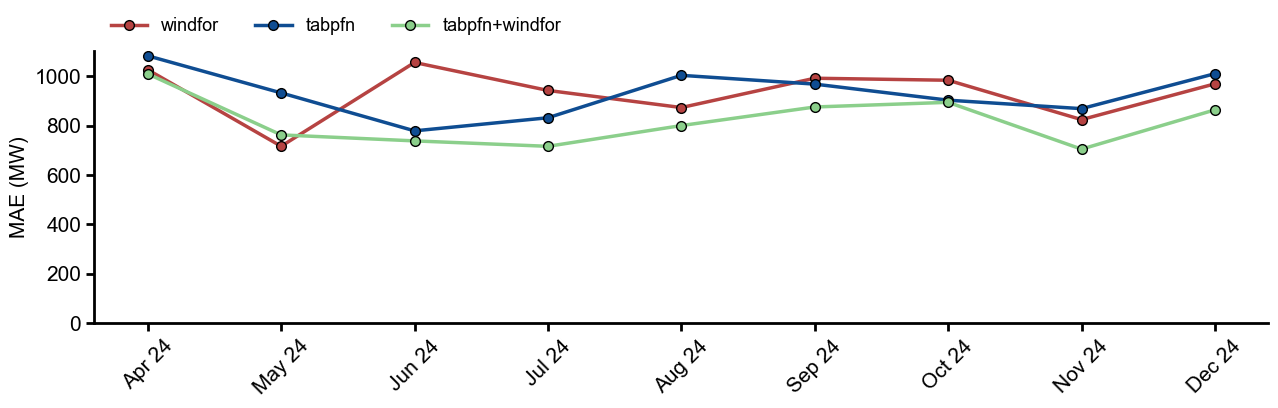

In [3]:
figures.monthly(err);

In [4]:
err.abs().groupby(pd.cut(test.lead_h, [15, 21, 27, 33, 40]), observed=True).mean().round(0)

,windfor,tabpfn,tabpfn+windfor
lead_h,,,
"(15, 21]",774.0,823.0,716.0
"(21, 27]",871.0,875.0,797.0
"(27, 33]",1030.0,1000.0,869.0
"(33, 40]",1037.0,1018.0,882.0
